In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/Users/anuj/Downloads/Taxidemand/train.csv")
type(df)

pandas.core.frame.DataFrame

In [2]:
df.head()
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [3]:
# Counting passangers if 0 or <=6 
df = df[(df.passenger_count > 0 ) & (df.passenger_count <=6)]
df['passenger_count'].unique()


array([1, 6, 4, 2, 3, 5])

In [4]:
df =  pd.get_dummies(df, columns=['vendor_id'], prefix='vendor', drop_first=True)
df['vendor_2'] = df['vendor_2'].astype(int)

In [5]:
df.head()

,id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,vendor_2
0,id2875421,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,1
1,id2377394,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0
2,id3858529,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,1
3,id3504673,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,1
4,id2181028,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,1


In [5]:
df = df.drop("id",axis=1)
df.columns


Index(['pickup_datetime', 'dropoff_datetime', 'passenger_count',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'vendor_2'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1458579 entries, 0 to 1458643
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   pickup_datetime     1458579 non-null  object 
 1   dropoff_datetime    1458579 non-null  object 
 2   passenger_count     1458579 non-null  int64  
 3   pickup_longitude    1458579 non-null  float64
 4   pickup_latitude     1458579 non-null  float64
 5   dropoff_longitude   1458579 non-null  float64
 6   dropoff_latitude    1458579 non-null  float64
 7   store_and_fwd_flag  1458579 non-null  object 
 8   trip_duration       1458579 non-null  int64  
 9   vendor_2            1458579 non-null  int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 122.4+ MB


In [6]:
# Convert pandas series into datetime object
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

In [7]:
# Extract features by converting pickup_datetime into datetime object
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.day
df['pickup_weekday'] = df['pickup_datetime'].dt.weekday
df['is_weekend'] = df['pickup_weekday'].isin([5,6]).astype(int)
df['pickup_month'] = df['pickup_datetime'].dt.month

In [8]:
df = df[
    df.pickup_latitude.between(
        df.pickup_latitude.quantile(0.01),
        df.pickup_latitude.quantile(0.99)
    ) &
    df.dropoff_latitude.between(
        df.dropoff_latitude.quantile(0.01),
        df.dropoff_latitude.quantile(0.99)
    ) &
    df.pickup_longitude.between(
        df.pickup_longitude.quantile(0.01),
        df.pickup_longitude.quantile(0.99)
    ) &
    df.dropoff_longitude.between(
        df.dropoff_longitude.quantile(0.01),
        df.dropoff_longitude.quantile(0.99)
    )
]

In [9]:
import numpy as np

# Haversine Formula
def haversine(lat1, lat2, lon1, lon2):
    # distance between longitude and lattitude
    dlat = (lat2 -lat1) * np.pi / 180.0
    dlon = (lon2 - lon1) * np.pi / 180.0

    lat1 = (lat1) * np.pi / 180.0
    lat2 = (lat2) * np.pi / 180.0

    inside_part = (pow(np.sin(dlat / 2),2) +
                   pow(np.sin(dlon / 2),2) * np.cos(lat1) * np.cos(lat2)) 
    radius_of_earth = 6371
    haversine_formula = 2 * radius_of_earth * np.arcsin(np.sqrt(inside_part))
    return haversine_formula


In [10]:
df['total_distance_km'] = haversine(
    df.pickup_latitude , df.dropoff_latitude,
    df.pickup_longitude, df.dropoff_longitude
)

In [11]:
# Manhattan Distance 
df['manhattan_distance']= (
    abs(df['pickup_latitude'] - df['dropoff_latitude']) +
    abs(df['pickup_longitude'] - df['dropoff_longitude'])
)


In [12]:
# Bearing for direction
def bearing(lat1,lat2,lon1,lon2):
    
    # converting latitude an longitude into radian
    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    lon1 = np.radians(lon1)
    lon2 = np.radians(lon2)



    delta_Y = lon2 - lon1
    # compute intermediate values
    X = np.sin(delta_Y) * np.cos(lat2)
    Y = (np.cos(lat1) * np.sin(lat2)) - np.sin(lat1) * np.cos(lat2) * np.cos(delta_Y)

    # compute angle
    theta = np.arctan2(X,Y) 
    # use arctan2 as it returns between -180 degree and 180 degree , so 
    return (theta * 180 / np.pi + 360) % 360

In [13]:
df['bearing_direction'] = bearing(
    df['pickup_latitude'],  df['dropoff_latitude'],
    df['pickup_longitude'], df['dropoff_longitude'])

In [14]:
# making clusters is to capture "hotspots" in the city areas with lots of pickups or dropoffs
from sklearn.cluster import KMeans

pickup_coords = df[['pickup_latitude','pickup_longitude']]
dropoff_coords = df[['dropoff_latitude','dropoff_longitude']]

kmeans = KMeans(n_clusters=50,random_state=42)
# pickup cluster
df['pickup_cluster'] = kmeans.fit_predict(pickup_coords)

# Dropoff cluster
df['dropoff_cluster'] = kmeans.fit_predict(dropoff_coords)

/Users/anuj/anaconda3/envs/NLP/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/anuj/anaconda3/envs/NLP/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [15]:
# Trip duration has a long-tail distribution, i.e., a few extremely long trips.
# if use plain trip_duration as target in regression,those outliers can dominate error metrics.
df['trip_duration'] = np.log1p(df['trip_duration'])
df.head()

,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,vendor_2,pickup_hour,pickup_day,pickup_weekday,is_weekend,pickup_month,total_distance_km,manhattan_distance,bearing_direction,pickup_cluster,dropoff_cluster
0,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,6.122493,1,17,14,0,0,3,1.498521,0.019859,99.970196,36,25
1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,6.498282,0,0,12,6,1,6,1.805507,0.026478,242.846232,44,26
2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,7.661527,1,11,19,1,0,1,6.385098,0.080158,200.319835,36,22
3,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,6.063785,1,19,6,2,0,4,1.485498,0.015480,187.262300,6,22
4,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,6.077642,1,13,26,5,1,3,1.188588,0.010818,179.473585,41,16


In [16]:
# Rush hour time
df['rush_hour'] = df['pickup_hour'].isin([6,7,8,9,16,17,18,19,20]).astype(int)

# converting object into int
#Whether the trip record was stored in the taxi’s memory first and sent later to the server.
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'Y':1, 'N':0})

In [17]:
df_preprocessed = df.drop(columns=[
    'pickup_datetime', 'dropoff_datetime',
    'pickup_latitude', 'pickup_longitude',
    'dropoff_latitude', 'dropoff_longitude',
])

### EDA after Data cleaning and Feature engineering

In [20]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)


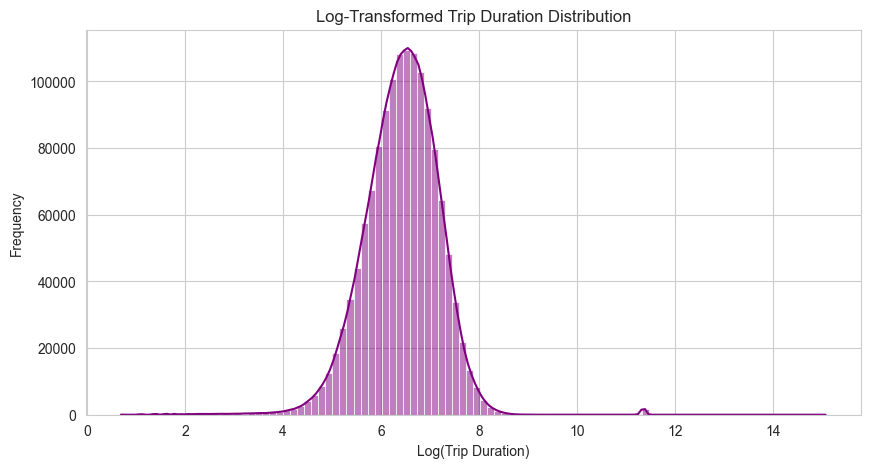

In [21]:
# 1 Trip Duration Distribution (log-transformed)
plt.figure(figsize=(10,5))
sns.histplot(df_preprocessed['trip_duration'], bins=100, kde=True, color='purple')
plt.title("Log-Transformed Trip Duration Distribution")
plt.xlabel("Log(Trip Duration)")
plt.ylabel("Frequency")
plt.show()


/var/folders/j8/32bg5cx54_b2c23ptj54gl580000gn/T/ipykernel_3559/1297632157.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='passenger_count', data=df_preprocessed, palette="Blues_d")


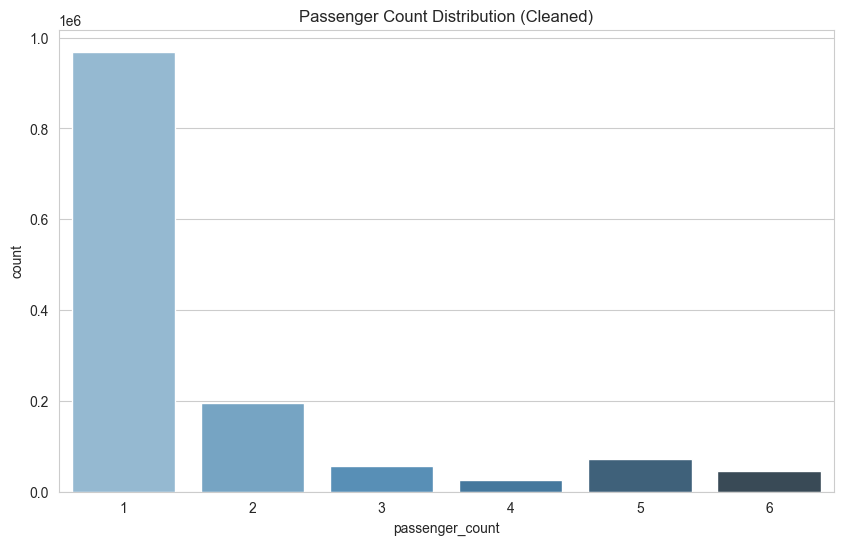

In [22]:
#Passenger Count Distribution
sns.countplot(x='passenger_count', data=df_preprocessed, palette="Blues_d")
plt.title("Passenger Count Distribution (Cleaned)")
plt.show()

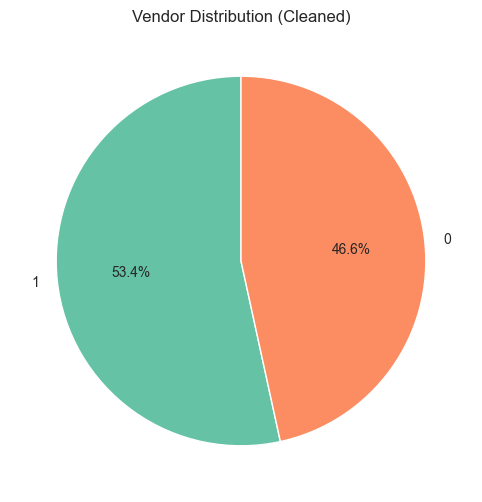

In [23]:
# Vendor Distribution
vendor_counts = df_preprocessed['vendor_2'].value_counts()
plt.pie(vendor_counts, labels=vendor_counts.index, autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette("Set2"))
plt.title("Vendor Distribution (Cleaned)")
plt.show()



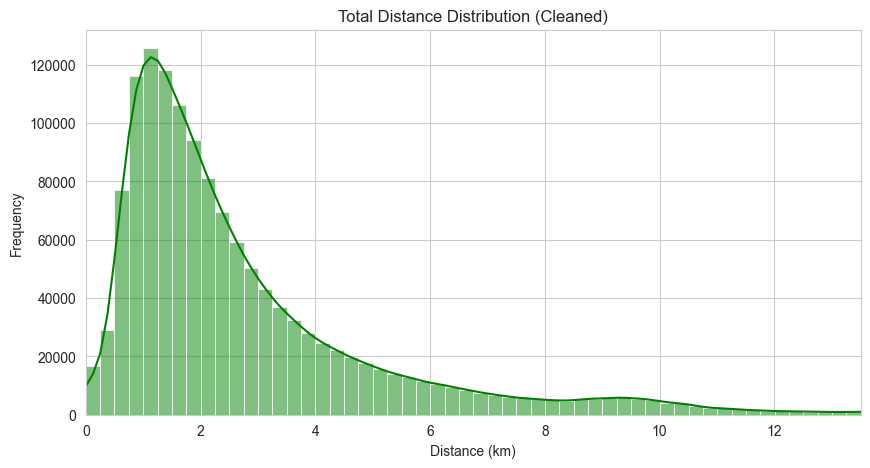

In [24]:
# Total Distance Distribution
plt.figure(figsize=(10,5))
sns.histplot(df_preprocessed['total_distance_km'], bins=100, kde=True, color='green')
plt.title("Total Distance Distribution (Cleaned)")
plt.xlabel("Distance (km)")
plt.ylabel("Frequency")
plt.xlim(0, df_preprocessed['total_distance_km'].quantile(0.99))
plt.show()

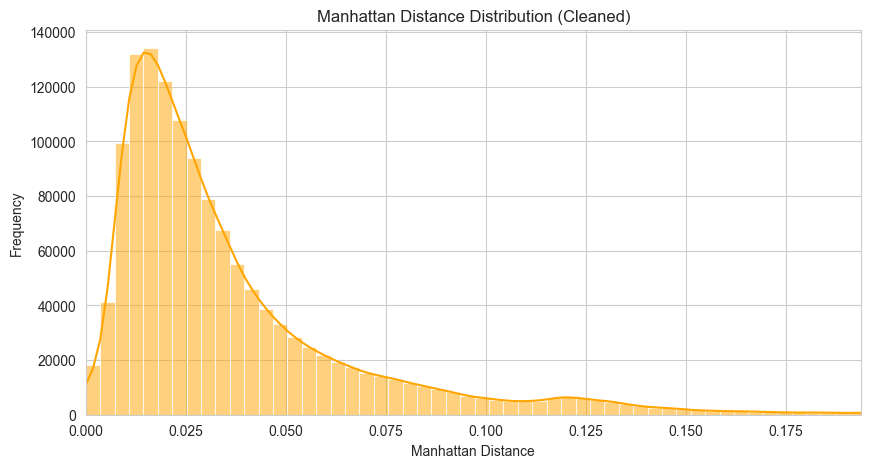

In [25]:
# Manhattan Distance Distribution
plt.figure(figsize=(10,5))
sns.histplot(df_preprocessed['manhattan_distance'], bins=100, kde=True, color='orange')
plt.title("Manhattan Distance Distribution (Cleaned)")
plt.xlabel("Manhattan Distance")
plt.ylabel("Frequency")
plt.xlim(0, df_preprocessed['manhattan_distance'].quantile(0.99))
plt.show()


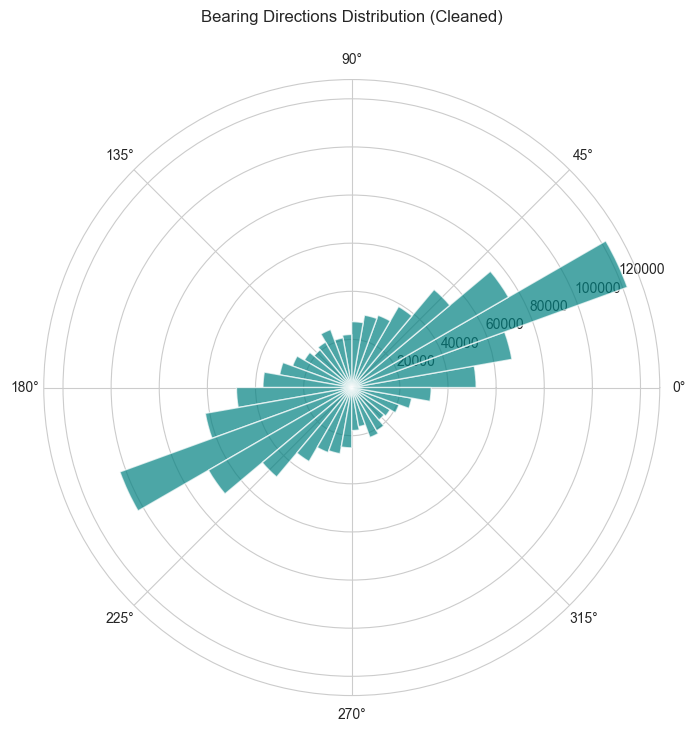

In [26]:
# Bearing Directions (Polar Histogram)
plt.figure(figsize=(8,8))
plt.subplot(projection='polar')
theta = np.deg2rad(df_preprocessed['bearing_direction'])
plt.hist(theta, bins=36, color='teal', alpha=0.7)
plt.title("Bearing Directions Distribution (Cleaned)", y=1.08)
plt.show()

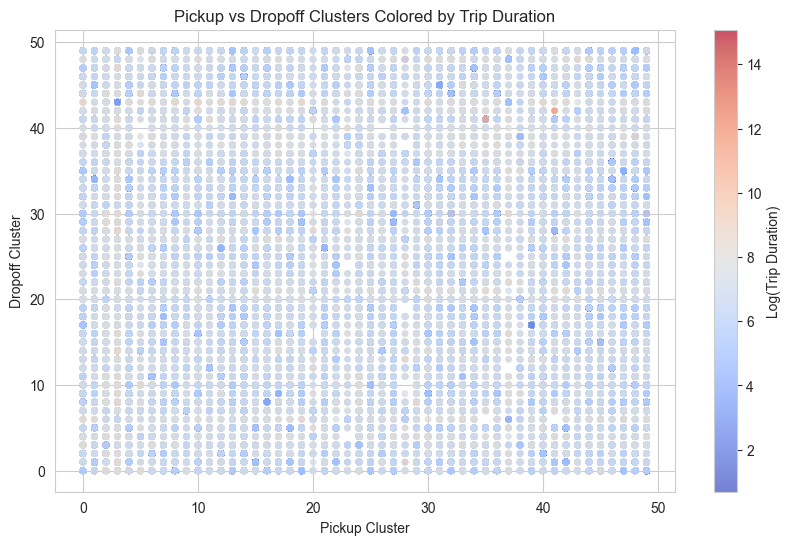

In [27]:
# Pickup vs Dropoff Clusters
plt.scatter(df_preprocessed['pickup_cluster'], df_preprocessed['dropoff_cluster'], 
            c=df_preprocessed['trip_duration'], cmap='coolwarm', s=15, alpha=0.7)
plt.colorbar(label="Log(Trip Duration)")
plt.xlabel("Pickup Cluster")
plt.ylabel("Dropoff Cluster")
plt.title("Pickup vs Dropoff Clusters Colored by Trip Duration")
plt.show()



/var/folders/j8/32bg5cx54_b2c23ptj54gl580000gn/T/ipykernel_3559/2832273904.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rush_hour', data=df_preprocessed, palette="coolwarm")


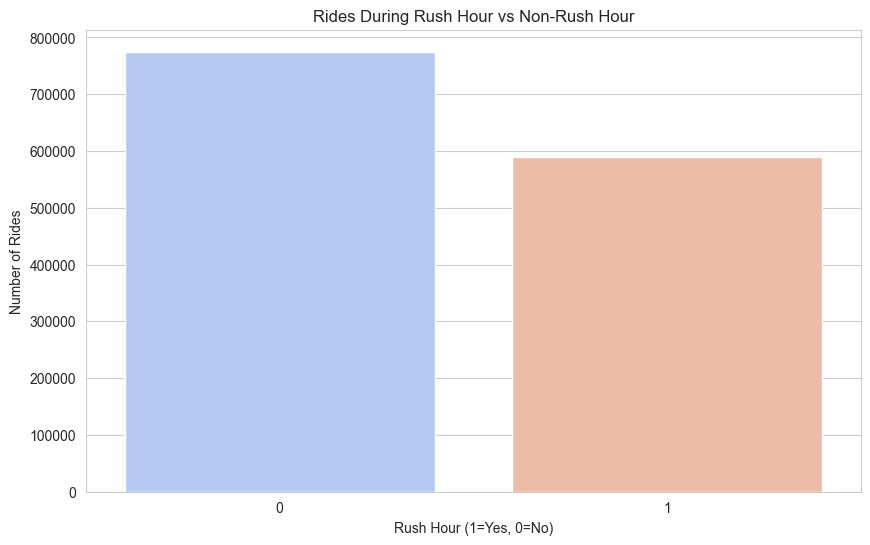

In [28]:
# Rush Hour vs Trip Count
sns.countplot(x='rush_hour', data=df_preprocessed, palette="coolwarm")
plt.title("Rides During Rush Hour vs Non-Rush Hour")
plt.xlabel("Rush Hour (1=Yes, 0=No)")
plt.ylabel("Number of Rides")
plt.show()



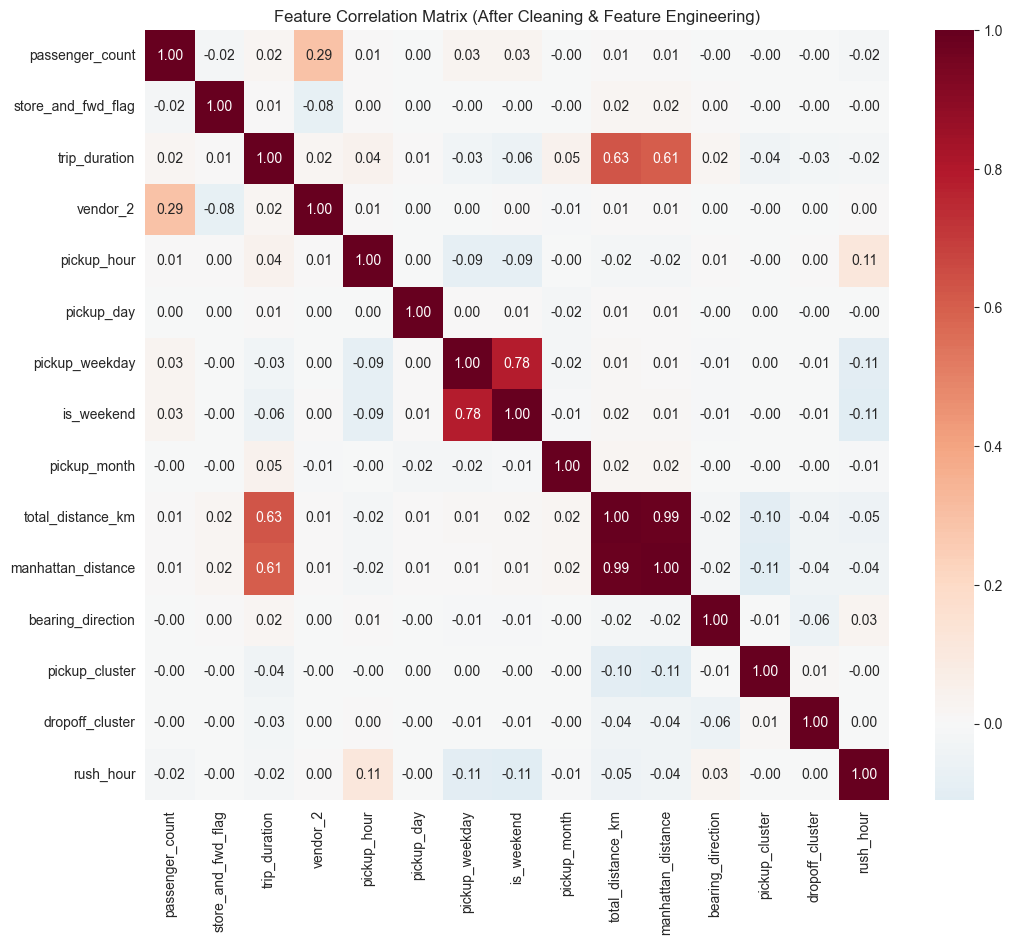

In [29]:
# 2 Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df_preprocessed.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Feature Correlation Matrix (After Cleaning & Feature Engineering)")
plt.show()

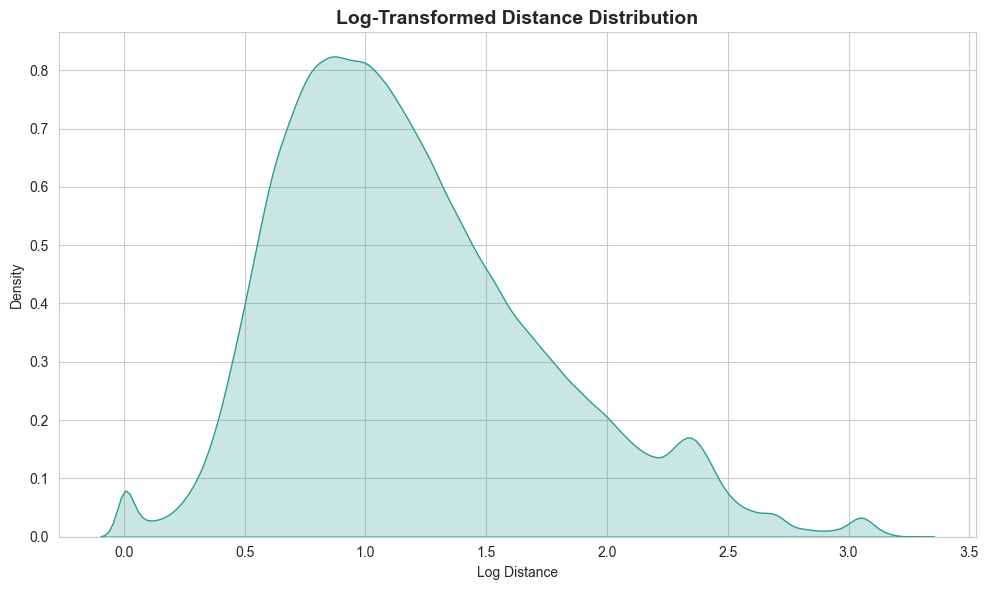

In [30]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    x=np.log1p(df_preprocessed['total_distance_km']),
    fill=True,
    color="#2A9D8F"
)

plt.title("Log-Transformed Distance Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Log Distance")
plt.tight_layout()
plt.show()

In [30]:
# Separate target variable
X = df_preprocessed.drop("trip_duration", axis=1)
y = df_preprocessed['trip_duration']

### Test Data Preprocessing

In [18]:
import pandas as pd
import numpy as np

df_test = pd.read_csv("/Users/anuj/Downloads/Taxidemand/test.csv")
df_test.head()



,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
0,id3004672,1,2016-06-30 23:59:58,1,-73.988129,40.732029,-73.990173,40.756680,N
1,id3505355,1,2016-06-30 23:59:53,1,-73.964203,40.679993,-73.959808,40.655403,N
2,id1217141,1,2016-06-30 23:59:47,1,-73.997437,40.737583,-73.986160,40.729523,N
3,id2150126,2,2016-06-30 23:59:41,1,-73.956070,40.771900,-73.986427,40.730469,N
4,id1598245,1,2016-06-30 23:59:33,1,-73.970215,40.761475,-73.961510,40.755890,N


In [19]:
# Filter Passange count
df_test= df_test[(df_test.passenger_count > 0) & (df_test.passenger_count <= 6)] 

In [20]:
# Vendor dummies
df_test = pd.get_dummies(df_test, columns=['vendor_id'], prefix='vendor', drop_first=True)
df_test['vendor_2'] = df_test['vendor_2'].astype(int)

In [21]:
# Convert date_time into datetime object
df_test['pickup_datetime'] = pd.to_datetime(df_test['pickup_datetime'])

In [22]:
# Time base fatures
df_test['pickup_hour'] = df_test['pickup_datetime'].dt.hour
df_test['pickup_day'] = df_test['pickup_datetime'].dt.day
df_test['pickup_weekday'] = df_test['pickup_datetime'].dt.weekday
df_test['is_weekend'] = df_test['pickup_weekday'].isin([5,6]).astype(int)
df_test['pickup_month'] = df_test['pickup_datetime'].dt.month

In [23]:
# Store and fwd flag mapping
df_test['store_and_fwd_flag'] = df_test['store_and_fwd_flag'].map({'Y':1,'N':0})

In [24]:
df_test = df_test[
    df_test.pickup_latitude.between(
        df_test.pickup_latitude.quantile(0.01),
        df_test.pickup_latitude.quantile(0.99)
    ) &
    df_test.dropoff_latitude.between(
        df_test.dropoff_latitude.quantile(0.01),
        df_test.dropoff_latitude.quantile(0.99)
    ) &
    df_test.pickup_longitude.between(
        df_test.pickup_longitude.quantile(0.01),
        df_test.pickup_longitude.quantile(0.99)
    ) &
    df_test.dropoff_longitude.between(
        df_test.dropoff_longitude.quantile(0.01),
        df_test.dropoff_longitude.quantile(0.99)
    )
]

In [25]:
# Distance by Haversine and manhattan, and direction by bearing
import numpy as np

# Haversine Formula
def haversine(lat1, lat2, lon1, lon2):
    # distance between longitude and lattitude
    dlat = (lat2 -lat1) * np.pi / 180.0
    dlon = (lon2 - lon1) * np.pi / 180.0

    lat1 = (lat1) * np.pi / 180.0
    lat2 = (lat2) * np.pi / 180.0

    inside_part = (pow(np.sin(dlat / 2),2) +
                   pow(np.sin(dlon / 2),2) * np.cos(lat1) * np.cos(lat2)) 
    radius_of_earth = 6371
    haversine_formula = 2 * radius_of_earth * np.arcsin(np.sqrt(inside_part))
    return haversine_formula

# Bearing for direction
def bearing(lat1,lat2,lon1,lon2):
    
    # converting latitude an longitude into radian
    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    lon1 = np.radians(lon1)
    lon2 = np.radians(lon2)



    delta_Y = lon2 - lon1
    # compute intermediate values
    X = np.sin(delta_Y) * np.cos(lat2)
    Y = (np.cos(lat1) * np.sin(lat2)) - np.sin(lat1) * np.cos(lat2) * np.cos(delta_Y)

    # compute angle
    theta = np.arctan2(X,Y) 
    # use arctan2 as it returns between -180 degree and 180 degree , so 
    return (theta * 180 / np.pi + 360) % 360

df_test['total_distance_km'] = haversine(
    df_test.pickup_latitude , df_test.dropoff_latitude,
    df_test.pickup_longitude, df_test.dropoff_longitude
)

# Manhattan Distance 
df_test['manhattan_distance']= (
    abs(df_test['pickup_latitude'] - df_test['dropoff_latitude']) +
    abs(df_test['pickup_longitude'] - df_test['dropoff_longitude'])
)

df_test['bearing_direction'] = bearing(
    df_test['pickup_latitude'],  df_test['dropoff_latitude'],
    df_test['pickup_longitude'], df_test['dropoff_longitude'])


In [26]:


test_pickup_coords = df_test[['pickup_latitude','pickup_longitude']]
test_dropoff_coords = df_test[['dropoff_latitude','dropoff_longitude']]
# pickup cluster
df_test['pickup_cluster'] = kmeans.fit_predict(test_pickup_coords)

# Dropoff cluster
df_test['dropoff_cluster'] = kmeans.fit_predict(test_dropoff_coords)

/Users/anuj/anaconda3/envs/NLP/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/anuj/anaconda3/envs/NLP/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [27]:
# Rush hour time
df_test['rush_hour'] = df_test['pickup_hour'].isin([6,7,8,9,16,17,18,19,20]).astype(int)

df_test_preprocessed = df_test.drop(columns=['id',
    'pickup_datetime',
    'pickup_latitude', 'pickup_longitude',
    'dropoff_latitude', 'dropoff_longitude',
])

## Train Test Split

In [31]:
from sklearn.model_selection import train_test_split

X_train,X_val,y_train,y_val = train_test_split(X,y,random_state=42,test_size=0.2)

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

st = StandardScaler()
preprocesser = ColumnTransformer(
    transformers=[
        ('numeric', st,list(X_train.columns))
    ]
)
preprocesser.fit(X_train)

ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                 ['passenger_count', 'store_and_fwd_flag',
                                  'vendor_2', 'pickup_hour', 'pickup_day',
                                  'pickup_weekday', 'is_weekend',
                                  'pickup_month', 'total_distance_km',
                                  'manhattan_distance', 'bearing_direction',
                                  'pickup_cluster', 'dropoff_cluster',
                                  'rush_hour'])])

## Linear Regression

In [33]:
from sklearn.linear_model import LinearRegression
pipeline = Pipeline(
    steps = [
        ("preprocesser",preprocesser),
        ("Linear Regression",LinearRegression())
    ]
)

In [34]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocesser',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['passenger_count',
                                                   'store_and_fwd_flag',
                                                   'vendor_2', 'pickup_hour',
                                                   'pickup_day',
                                                   'pickup_weekday',
                                                   'is_weekend', 'pickup_month',
                                                   'total_distance_km',
                                                   'manhattan_distance',
                                                   'bearing_direction',
                                                   'pickup_cluster',
                                                   'dropoff_cluster',
                                                   'rush_hour'])])),
                ('Linear Regression', LinearRegression())])

In [35]:
from sklearn.metrics import mean_squared_error
import numpy as np

pred_val = pipeline.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, pred_val))
print("Validation RMSE:", rmse)

Validation RMSE: 0.5793948080184377


In [36]:
from sklearn.metrics import r2_score

r2 = r2_score(y_val, pred_val)
print("R² score:", r2)

R² score: 0.4175295747166071


In [37]:
test_pred = pipeline.predict(df_test_preprocessed)
print(test_pred)

[6.71790054 6.62686342 6.23388477 ... 6.78373186 7.28222195 7.08860889]


## Random Forest Regressor

In [49]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer

preprocesser_random = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', list(X_train.columns))
    ]
)

In [50]:
pipeline_random = Pipeline(
    steps=[
        ("preprocessing", preprocesser_random),
        ("model", RandomForestRegressor(
            n_estimators=500,
            max_depth=None,       # None = grow until all leaves are pure
            random_state=42,
            n_jobs=-1             # use all CPU cores
        ))
    ]
)

In [51]:
pipeline_random.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['passenger_count',
                                                   'store_and_fwd_flag',
                                                   'vendor_2', 'pickup_hour',
                                                   'pickup_day',
                                                   'pickup_weekday',
                                                   'is_weekend', 'pickup_month',
                                                   'total_distance_km',
                                                   'manhattan_distance',
                                                   'bearing_direction',
                                                   'pickup_cluster',
                                                   'dropoff_cluster',
                                                   'rush_hour'])])),
                ('model',
                 RandomForestRegressor(n_estimators=500, n_jobs=-1,
                                       random_state=42))])

In [52]:
from sklearn.metrics import mean_squared_error
import numpy as np

pred_val = pipeline_random.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, pred_val))
print("Validation RMSE:", rmse)

Validation RMSE: 0.4093687197267586


In [62]:
X_test = df_test  # df_test is your X_test
test_pred = pipeline_random.predict(df_test_preprocessed)
print(test_pred)

[6.51560511 6.83445894 6.12190703 ... 7.06764074 7.29146068 7.04602156]


In [94]:
from sklearn.metrics import r2_score

r2 = r2_score(y_val, pred_val)
print("R² score:", r2)

R² score: 0.709227058241436


## XGBoostRegressor

In [38]:
from xgboost import XGBRegressor

In [39]:
xgb_reg = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=0
)
xgb_reg.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.1, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=3, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=800, n_jobs=None,
             num_parallel_tree=None, random_state=0, ...)

In [40]:

pred_test = xgb_reg.predict(df_test_preprocessed)
print(pred_test[:10])
y_pred = xgb_reg.predict(X_val)

[6.544944  6.6891665 6.1061463 7.109097  5.870415  6.9324284 6.774582
 6.4064636 6.1708546 5.329797 ]


In [41]:
from sklearn.metrics import r2_score

y_val_pred = xgb_reg.predict(X_val)
r2 = r2_score(y_val, y_val_pred)
print(f"Validation R2 score: {r2:.4f}")

Validation R2 score: 0.7266


In [42]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
print("Validation RMSE:", rmse)

Validation RMSE: 0.3969784592870716


/var/folders/j8/32bg5cx54_b2c23ptj54gl580000gn/T/ipykernel_3559/1646419558.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


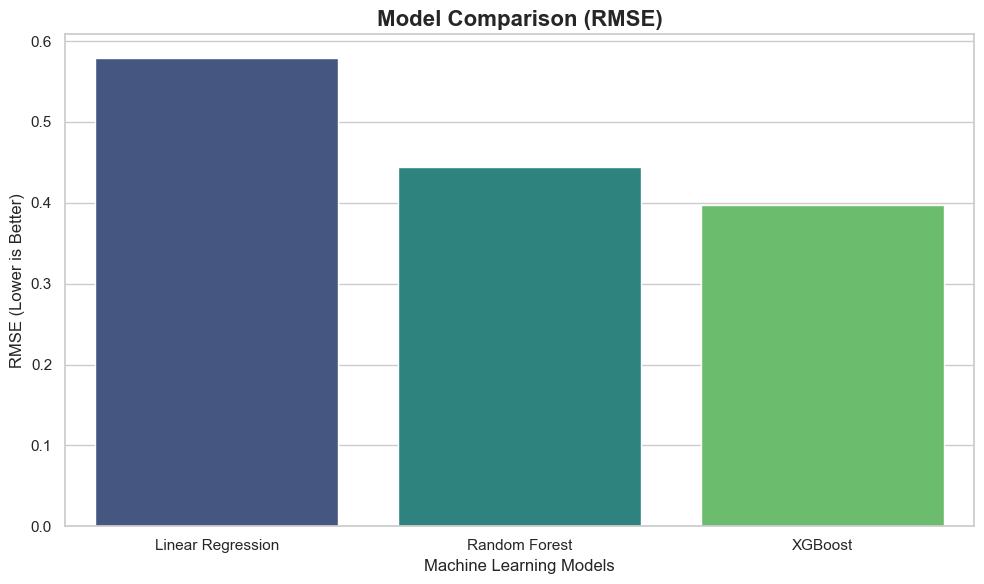

In [104]:
#Model Comparison – RMSE Bar Chart
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Model results
models = ['Linear Regression', 'Random Forest', 'XGBoost']
rmse_scores = [0.5793948080184377, 0.4439686683925789, 0.3969784592870716]

results_df = pd.DataFrame({
    "Model": models,
    "RMSE": rmse_scores
})

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE",
    palette="viridis"
)

plt.title("Model Comparison (RMSE)", fontsize=16, fontweight='bold')
plt.ylabel("RMSE (Lower is Better)")
plt.xlabel("Machine Learning Models")

plt.tight_layout()
plt.show()

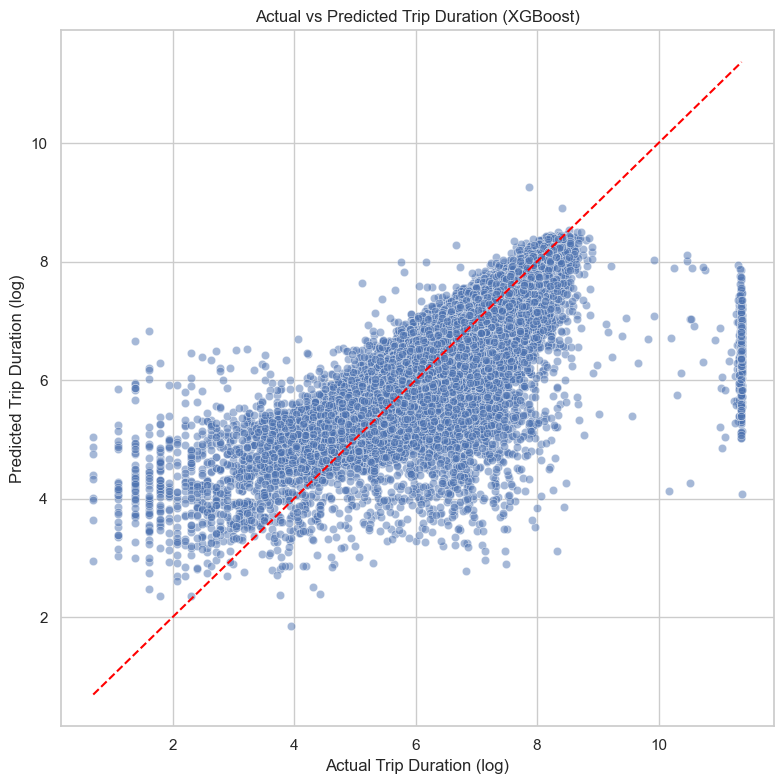

In [106]:
# Predicted vs Actual Plot (Best Model)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,8))

sns.scatterplot(
    x=y_val,
    y=y_val_pred,  # your XGBoost predictions
    alpha=0.5
)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual Trip Duration (log)")
plt.ylabel("Predicted Trip Duration (log)")
plt.title("Actual vs Predicted Trip Duration (XGBoost)")

plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

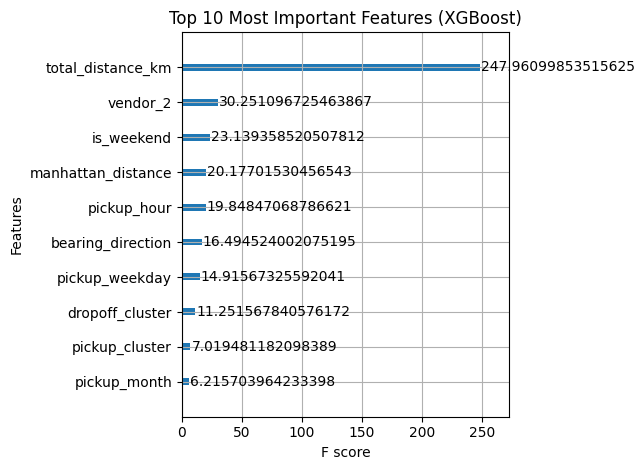

In [45]:
#Feature Importance (XGBoost)
import xgboost as xgb
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

xgb.plot_importance(
    xgb_reg,
    max_num_features=10,
    importance_type='gain'
)

plt.title("Top 10 Most Important Features (XGBoost)")
plt.tight_layout()
plt.show()

## GridSearchCV - XGBoost

In [43]:
from sklearn.model_selection import GridSearchCV
params = {
    "n_estimators": [200, 400, 600],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1]
}

grid = GridSearchCV(xgb_reg,params, cv=5, scoring='r2')
grid.fit(X_train,y_train)
print(grid.best_params_)


{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 600, 'subsample': 0.8}


In [47]:
best_model = grid.best_estimator_

In [53]:
y_pred_grid = best_model.predict(X_val)
from sklearn.metrics import r2_score

grid_r2 = r2_score(y_val, y_pred_grid)
print("R² score:", grid_r2)

R² score: 0.7269016939159942


In [49]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE:", rmse)

RMSE: 0.39673193710958954


## CatBoost Regressor

In [59]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(verbose=0)
model.fit(X_train, y_train)

y_pred_cat = model.predict(X_val)


cat_r2 = r2_score(y_val, y_pred_cat)
print("R² score:", cat_r2)

cat_rmse = np.sqrt(mean_squared_error(y_val,y_pred_cat))
print("Cat_rmse:",cat_rmse)

R² score: 0.7222911823715151
Cat_rmse: 0.40006678327563616


## LightGBM Regressor

In [61]:
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

model = LGBMRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print("R2:", r2_score(y_val, y_pred))
lightgbm_rmse = np.sqrt(mean_squared_error(y_val,y_pred_cat))
print("LightGBM:",lightgbm_rmse)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014618 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 950
[LightGBM] [Info] Number of data points in the train set: 1091932, number of used features: 14
[LightGBM] [Info] Start training from score 6.422446
R2: 0.7032425798716149
LightGBM: 0.40006678327563616
